In [1]:
# Data handling
import pandas as pd
import numpy as np

# Visualization
import matplotlib.pyplot as plt
import seaborn as sns

# Machine Learning
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, roc_auc_score

# Explainability
import shap

# Suppress warnings
import warnings
warnings.filterwarnings("ignore")


In [2]:
df = pd.read_csv("shopping_trends.csv")
df.head()


,Customer ID,Age,Gender,Item Purchased,Category,Purchase Amount (USD),Location,Size,Color,Season,Review Rating,Subscription Status,Payment Method,Shipping Type,Discount Applied,Promo Code Used,Previous Purchases,Preferred Payment Method,Frequency of Purchases
0,1,55,Male,Blouse,Clothing,53,Kentucky,L,Gray,Winter,3.1,Yes,Credit Card,Express,Yes,Yes,14,Venmo,Fortnightly
1,2,19,Male,Sweater,Clothing,64,Maine,L,Maroon,Winter,3.1,Yes,Bank Transfer,Express,Yes,Yes,2,Cash,Fortnightly
2,3,50,Male,Jeans,Clothing,73,Massachusetts,S,Maroon,Spring,3.1,Yes,Cash,Free Shipping,Yes,Yes,23,Credit Card,Weekly
3,4,21,Male,Sandals,Footwear,90,Rhode Island,M,Maroon,Spring,3.5,Yes,PayPal,Next Day Air,Yes,Yes,49,PayPal,Weekly
4,5,45,Male,Blouse,Clothing,49,Oregon,M,Turquoise,Spring,2.7,Yes,Cash,Free Shipping,Yes,Yes,31,PayPal,Annually


In [4]:
df.columns


Index(['Customer ID', 'Age', 'Gender', 'Item Purchased', 'Category',
       'Purchase Amount (USD)', 'Location', 'Size', 'Color', 'Season',
       'Review Rating', 'Subscription Status', 'Payment Method',
       'Shipping Type', 'Discount Applied', 'Promo Code Used',
       'Previous Purchases', 'Preferred Payment Method',
       'Frequency of Purchases'],
      dtype='object')

In [5]:
customer_df = df.groupby('Customer ID').agg({
    'Purchase Amount (USD)': 'sum',
    'Previous Purchases': 'max',
    'Review Rating': 'mean'
}).reset_index()

customer_df.rename(columns={
    'Purchase Amount (USD)': 'total_spent',
    'Previous Purchases': 'total_orders',
    'Review Rating': 'avg_review_rating'
}, inplace=True)

customer_df.head()


,Customer ID,total_spent,total_orders,avg_review_rating
0,1,53,14,3.1
1,2,64,2,3.1
2,3,73,23,3.1
3,4,90,49,3.5
4,5,49,31,2.7


In [6]:
customer_df['avg_order_value'] = (
    customer_df['total_spent'] / customer_df['total_orders']
)


In [7]:
df['Discount Applied'] = df['Discount Applied'].map({
    'Yes': 1,
    'No': 0
})


In [8]:
offer_df = df.groupby('Customer ID')['Discount Applied'].max().reset_index()

customer_df = customer_df.merge(offer_df, on='Customer ID')
customer_df.rename(columns={'Discount Applied': 'offer_accepted'}, inplace=True)

customer_df.head()


,Customer ID,total_spent,total_orders,avg_review_rating,avg_order_value,offer_accepted
0,1,53,14,3.1,3.785714,1
1,2,64,2,3.1,32.000000,1
2,3,73,23,3.1,3.173913,1
3,4,90,49,3.5,1.836735,1
4,5,49,31,2.7,1.580645,1


In [9]:
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report

X = customer_df[['avg_order_value', 'total_orders', 'avg_review_rating']]
y = customer_df['offer_accepted']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

model = RandomForestClassifier()
model.fit(X_train, y_train)

preds = model.predict(X_test)

print(classification_report(y_test, preds))


              precision    recall  f1-score   support

           0       0.55      0.68      0.61       422
           1       0.48      0.35      0.40       358

    accuracy                           0.52       780
   macro avg       0.51      0.51      0.50       780
weighted avg       0.52      0.52      0.51       780



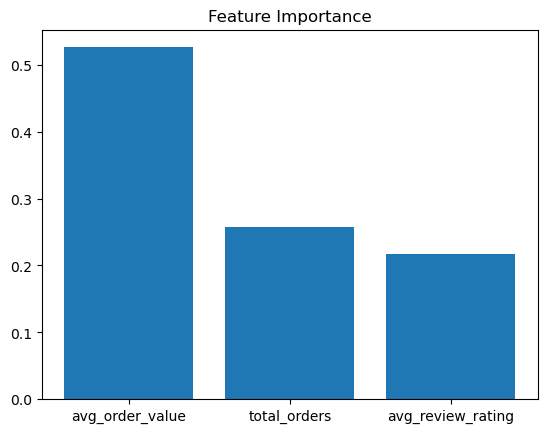

In [10]:
import matplotlib.pyplot as plt
importances = model.feature_importances_

plt.figure()
plt.bar(X.columns, importances)
plt.title("Feature Importance")
plt.show()


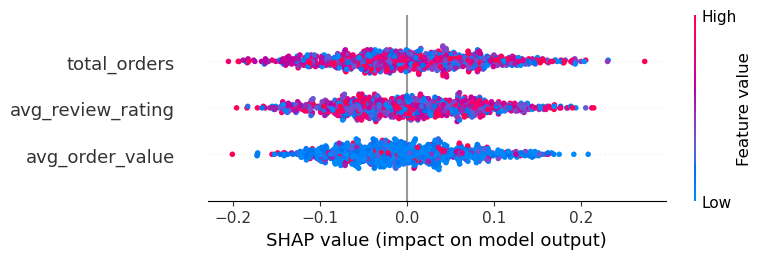

In [13]:
import shap

explainer = shap.TreeExplainer(model)

shap_values = explainer.shap_values(X_test)

# If shap returns list (old behavior)
if isinstance(shap_values, list):
    shap.summary_plot(shap_values[1], X_test)

# If shap returns 3D array (new behavior)
else:
    shap.summary_plot(shap_values[:, :, 1], X_test)



In [15]:
print(type(shap_values))
print(np.array(shap_values).shape)


<class 'numpy.ndarray'>
(780, 3, 2)


In [16]:
import pickle
pickle.dump(model, open("model.pkl", "wb"))


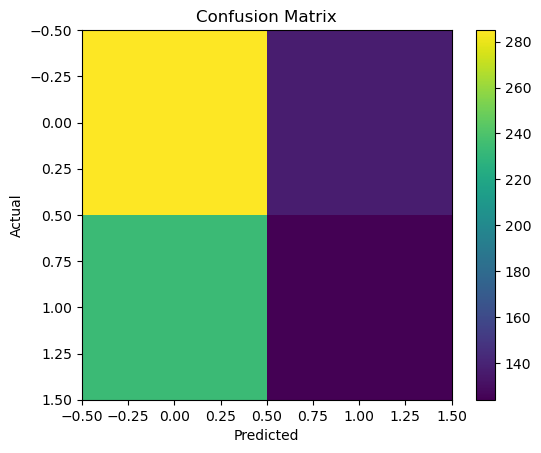

ROC-AUC Score: 0.5196457412163414


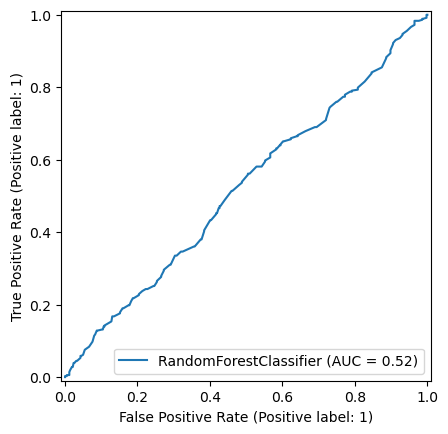

In [17]:
from sklearn.metrics import confusion_matrix, roc_auc_score, RocCurveDisplay
import matplotlib.pyplot as plt

# Confusion Matrix
cm = confusion_matrix(y_test, preds)

plt.figure()
plt.imshow(cm)
plt.title("Confusion Matrix")
plt.colorbar()
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

# ROC AUC
probs = model.predict_proba(X_test)[:, 1]
auc = roc_auc_score(y_test, probs)

print("ROC-AUC Score:", auc)

RocCurveDisplay.from_estimator(model, X_test, y_test)
plt.show()


In [18]:
# Encode Gender
customer_df['Gender'] = df.groupby('Customer ID')['Gender'].first().values
customer_df['Gender'] = customer_df['Gender'].map({'Male': 0, 'Female': 1})

# Add Subscription Status
sub_status = df.groupby('Customer ID')['Subscription Status'].first().reset_index()
sub_status['Subscription Status'] = sub_status['Subscription Status'].map({'Yes': 1, 'No': 0})

customer_df = customer_df.merge(sub_status, on='Customer ID')


In [20]:
X = customer_df[['avg_order_value','total_orders','avg_review_rating','Gender','Subscription Status']]


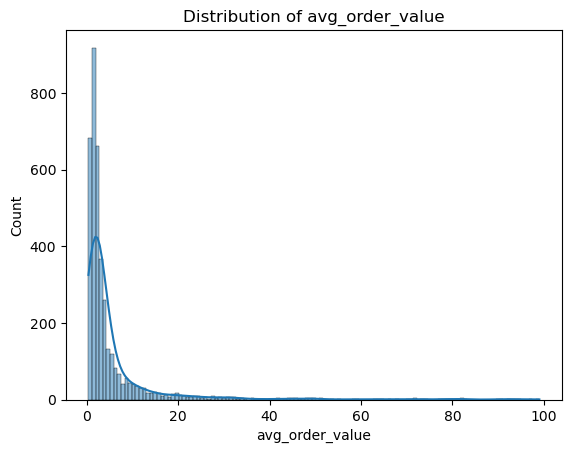

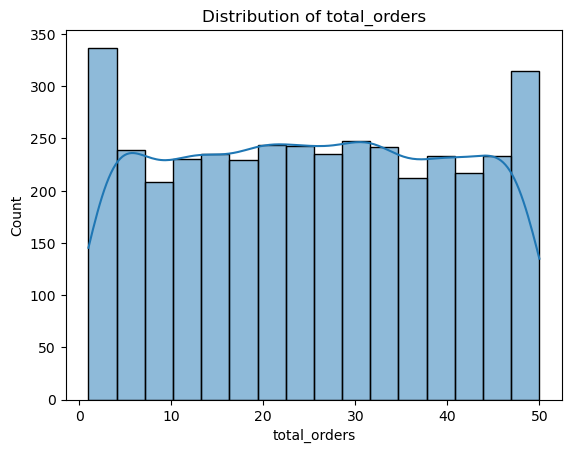

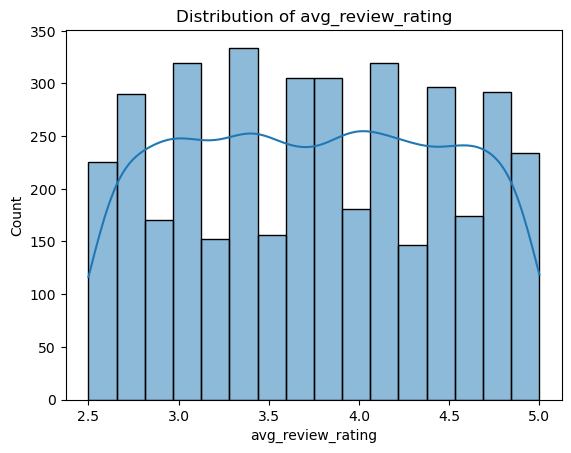

In [21]:
import matplotlib.pyplot as plt
import seaborn as sns

num_cols = ['avg_order_value', 'total_orders', 'avg_review_rating']

for col in num_cols:
    plt.figure()
    sns.histplot(X[col], kde=True)
    plt.title(f"Distribution of {col}")
    plt.show()


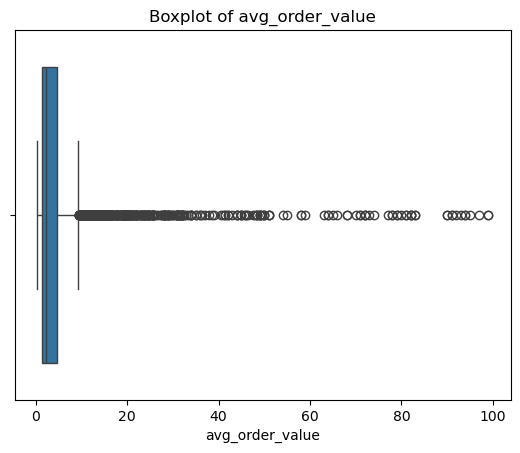

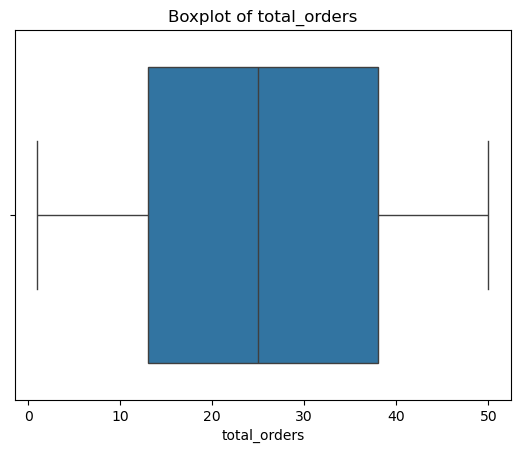

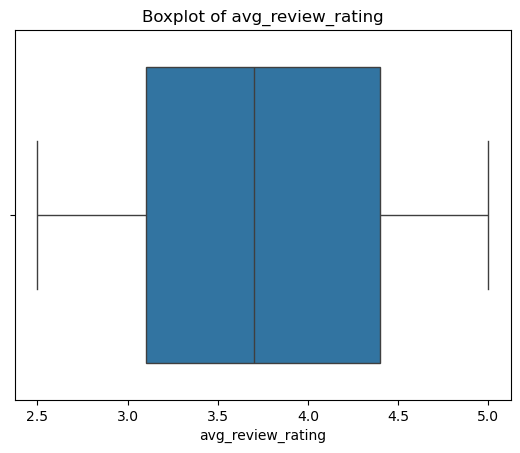

In [22]:
for col in num_cols:
    plt.figure()
    sns.boxplot(x=X[col])
    plt.title(f"Boxplot of {col}")
    plt.show()


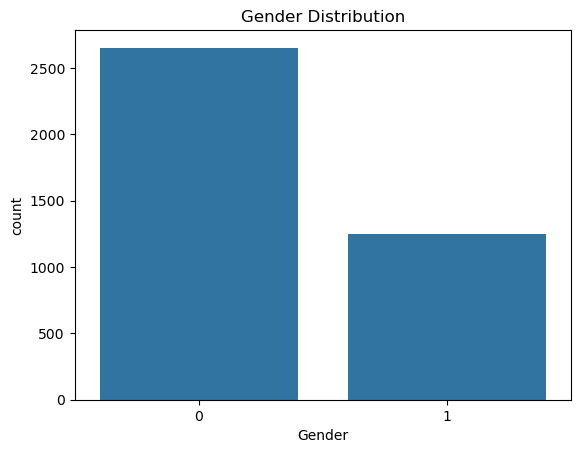

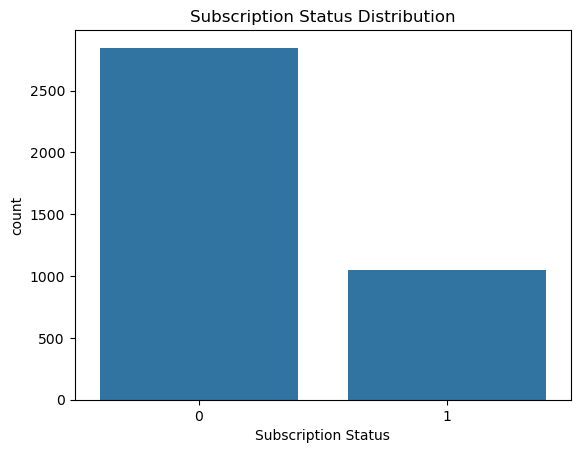

In [23]:
plt.figure()
sns.countplot(x=X['Gender'])
plt.title("Gender Distribution")
plt.show()

plt.figure()
sns.countplot(x=X['Subscription Status'])
plt.title("Subscription Status Distribution")
plt.show()


In [24]:
X.isnull().sum()


avg_order_value        0
total_orders           0
avg_review_rating      0
Gender                 0
Subscription Status    0
dtype: int64

In [25]:
X = X.dropna()


In [26]:
from sklearn.impute import SimpleImputer

imputer = SimpleImputer(strategy='mean')
X[num_cols] = imputer.fit_transform(X[num_cols])


In [27]:
X['Gender'] = X['Gender'].map({'Male': 0, 'Female': 1})
X['Subscription Status'] = X['Subscription Status'].map({'No': 0, 'Yes': 1})


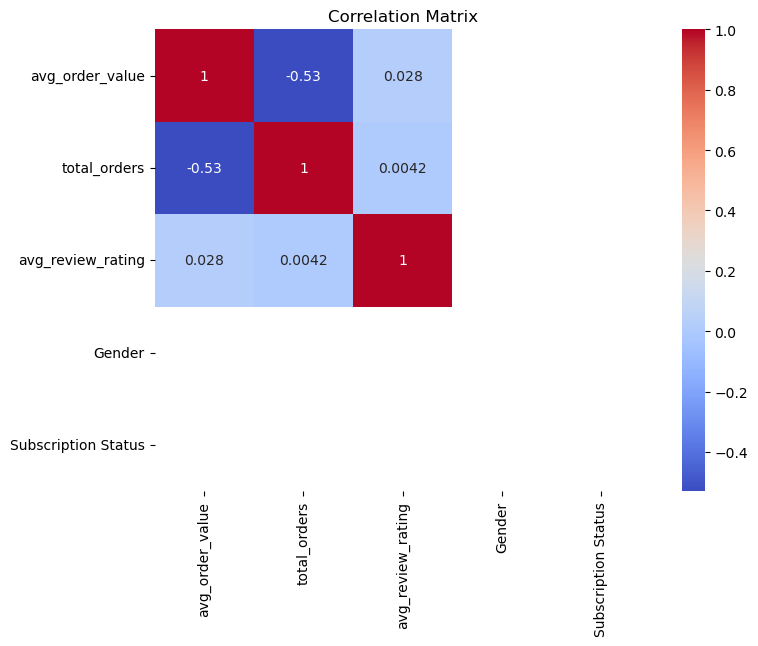

In [28]:
plt.figure(figsize=(8,6))
sns.heatmap(X.corr(), annot=True, cmap='coolwarm')
plt.title("Correlation Matrix")
plt.show()


In [29]:
from sklearn.model_selection import train_test_split

y = customer_df['offer_accepted']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)


In [30]:
from sklearn.ensemble import RandomForestClassifier

model = RandomForestClassifier(random_state=42)
model.fit(X_train, y_train)


,n_estimators,100
,criterion,'gini'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,'sqrt'
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


In [31]:
from sklearn.metrics import accuracy_score, classification_report

preds = model.predict(X_test)

print("Accuracy:", accuracy_score(y_test, preds))
print(classification_report(y_test, preds))


Accuracy: 0.5230769230769231
              precision    recall  f1-score   support

           0       0.55      0.66      0.60       422
           1       0.47      0.36      0.41       358

    accuracy                           0.52       780
   macro avg       0.51      0.51      0.50       780
weighted avg       0.51      0.52      0.51       780



In [32]:
from sklearn.metrics import roc_auc_score

probs = model.predict_proba(X_test)[:,1]
print("ROC-AUC:", roc_auc_score(y_test, probs))


ROC-AUC: 0.5148369032804682


In [33]:
print(X_train.columns)


Index(['avg_order_value', 'total_orders', 'avg_review_rating', 'Gender',
       'Subscription Status'],
      dtype='object')


In [34]:
print(model.feature_names_in_)


['avg_order_value' 'total_orders' 'avg_review_rating' 'Gender'
 'Subscription Status']


In [35]:
print(df['Gender'].unique())
print(df['Subscription Status'].unique())


['Male' 'Female']
['Yes' 'No']
